In [214]:
%load_ext autoreload 
%autoreload 2
%matplotlib inline
import json, os, cv2
from pathlib import Path
import numpy as np
import pandas as pd
from tqdm import tqdm
from scipy.interpolate import interp1d
from scipy import signal
from scipy.signal import find_peaks
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
from sklearn.cluster import KMeans
import matplotlib.colors as mcolors
from matplotlib.backends.backend_pdf import PdfPages
from matplotlib.gridspec import GridSpec 
import glob 
import seaborn as sns
from brokenaxes import brokenaxes
from frechetdist import frdist
from scipy.ndimage import gaussian_filter
from dipy.segment.metricspeed import AveragePointwiseEuclideanMetric
import ast
import scipy.stats as stats
from scipy.stats import f_oneway
from matplotlib import cm
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable



import sys
sys.path.insert(0, 'C:/Users/nlab/Documents/GitHub/obstacle_avoidance')

import warnings
warnings.filterwarnings('ignore')
from streamline_clustering.clustering import pair_elements,create_streamlines
from src.base import BaseInput
from src.topcam import Topcam
from src.utils.auxiliary import find_index_in_list,flatten_series
from pipeline.helper_functions import list_columns,interpolate_array,flatten_list_of_arrays,calculate_quartiles,create_df_by_type,split_range_into_parts,get_mean_of_df,get_median_of_df,drop_nans_in_columns,create_consective_df_new,assign_date_index,symmetrize_y_axis,edge_outliers,create_df_by_type_nostart,find_consecutive_repeats,largest_sequentially_increasing_by_one_subarray,create_color_dict,smooth,create_monotonic_array,correct_trace
#from pipeline.oa_calculations import distance_calcs,heading_calcs,cluster_obstacle,calculate_distances,df_tortuosity,deveation,lateral_error,start,redo_ts_trace,compute_tortuosity,angular_velocity_head,turn_direction,turn_to_obstacle,get_head_angle,head_angle_velocity,intial_lateral_error,avg_lateral_error,check_trial_for_obstalce_cross_df,distance_at_head_turn,zero_out_angle_target_port,angular_velocity_head_corner,intial_distance_to_obstacle,last_occurrence_indices,first_occurrence_indices,calculate_relative_distance_goal_ts
#from pipeline.oa_plotting_funcs import plot_arena,plot_orginal_obstacle,plot_obstacle_from_row
from pipeline.batch_process_oa import plot_oa
from pipeline.gaze_shift_functions import *
from pipeline.oa_with_cams_plotting_funcs import *
np.set_printoptions(suppress=True)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
def calculate_relative_distance(df):
    """calculates relavtive distance of nose to point on obstacle"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind,row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['head_cen_x_cm']
                    nose_y = row['head_cen_y_cm']
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']]) 
                        if np.isnan(e)==True:
                            distances.append(np.nan)
                        elif nose_y[i] > row['gt_obstacleTR_y_cm'] and nose_y[i] < row['gt_obstacleBR_y_cm'] :
                            obstalce_y = nose_y[i]
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                            
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTR_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBR_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)

                            
                except IndexError:
                    distances.append(np.nan)

                
                df.at[ind,'distance_from_edge'] = interpolate_array(np.array(distances)).astype(object)
                df.at[ind,'len_distance_from_edge'] =interpolate_array(np.array(distances)).astype(object).size
            if direction =='left':
                try:
                    nose_x = row['head_cen_x_cm']
                    nose_y = row['head_cen_y_cm']
                    distances = []
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']])
                        if np.isnan(e)==True:
                            distances.append(np.nan) 
                        elif nose_y[i] > row['gt_obstacleTL_y_cm'] and nose_y[i] < row['gt_obstacleBL_y_cm']:
                            obstalce_y = nose_y[i]
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTL_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBL_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                except IndexError:
                    distances.append(np.nan)
            
                df.at[ind,'distance_from_edge'] = interpolate_array(np.array(distances)).astype(object)
                df.at[ind,'len_distance_from_edge'] =interpolate_array(np.array(distances)).astype(object).size

In [170]:
def ts_calculate_relative_distance(df):
    """calculates relavtive distance of nose to point on obstacle"""
    for direction, direction_frame in df.groupby(['odd']):
        for ind,row in direction_frame.iterrows():  
            if direction == 'right':
                try:
                    nose_x = row['ts_head_cen_x_cm']
                    nose_y = row['ts_head_cen_y_cm']
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTR_x_cm'],row['gt_obstacleBR_x_cm']]) 
                        if np.isnan(e)==True:
                            distances.append(np.nan)
                        elif nose_y[i] > row['gt_obstacleTR_y_cm'] and nose_y[i] < row['gt_obstacleBR_y_cm'] :
                            obstalce_y = nose_y[i]
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                            
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTR_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBR_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] < obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] > obstalce_x:
                                    distance = distance 
                                    distances.append(distance)

                            
                except IndexError:
                    distances.append(np.nan)

                
                df.at[ind,'ts_distance_from_edge'] = interpolate_array(np.array(distances)).astype(object)
                df.at[ind,'len_ts_distance_from_edge'] =interpolate_array(np.array(distances)).astype(object).size
            if direction =='left':
                try:
                    nose_x = row['ts_head_cen_x_cm']
                    nose_y = row['ts_head_cen_y_cm']
                    distances = []
                    distances = []
                    for i,e in enumerate(nose_x):
                        obstalce_x = np.mean([row['gt_obstacleTL_x_cm'],row['gt_obstacleBL_x_cm']])
                        if np.isnan(e)==True:
                            distances.append(np.nan) 
                        elif nose_y[i] > row['gt_obstacleTL_y_cm'] and nose_y[i] < row['gt_obstacleBL_y_cm']:
                            obstalce_y = nose_y[i]
                            if nose_x[i] > obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) * -1
                                distances.append(distance)
                            if nose_x[i] < obstalce_x:
                                distance = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,obstalce_y)) 
                                distances.append(distance)
                        else:
                            distance_to_top = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleTL_y_cm']))
                            distance_to_bottom = np.abs(calculate_distances(nose_x[i],nose_y[i],obstalce_x,row['gt_obstacleBL_y_cm']))
                            if distance_to_top < distance_to_bottom:
                                distance = distance_to_top
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                            if distance_to_top > distance_to_bottom:
                                distance = distance_to_bottom
                                if nose_x[i] > obstalce_x:
                                    distance = distance * -1
                                    distances.append(distance)
                                if nose_x[i] < obstalce_x:
                                    distance = distance 
                                    distances.append(distance)
                except IndexError:
                    distances.append(np.nan)
            
                df.at[ind,'ts_distance_from_edge'] = interpolate_array(np.array(distances)).astype(object)
                df.at[ind,'len_ts_distance_from_edge'] =interpolate_array(np.array(distances)).astype(object).size

In [ ]:
def calculate_relative_distance_goal_ts(df):
    '''calculates change in distance from nose to goal port using trial start trace '''
    for direction, direction_frame in df.groupby(['odd']):
        for ind,row in direction_frame.iterrows():  
            if direction == 'right':
                nose_x = row['ts_head_cen_x_cm'].astype(float)
                nose_y = row['ts_head_cen_y_cm'].astype(float)
                port_x_tar = row.leftspout_x_cm
                port_y_tar = row.leftspout_y_cm
                port_x_start = row.rightspout_x_cm
                port_y_start = row.rightspout_y_cm
                distances_tar = []
                distances_start = []
                for i,e in enumerate(nose_x):
                  distance_tar = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_tar,port_y_tar))
                  distance_start = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_start,port_y_start))
                  distances_tar.append(distance_tar)
                  distances_start.append(distance_start)
                df.at[ind,'ts_distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind,'ts_distance_from_start_port'] = np.array(distances_start).astype(object)

            else:
                nose_x = row['ts_head_cen_x_cm'].astype(float)
                nose_y = row['ts_head_cen_y_cm'].astype(float)
                port_x_tar = row.rightspout_x_cm
                port_y_tar = row.rightspout_y_cm
                port_x_start = row.leftspout_x_cm
                port_y_start = row.leftspout_y_cm
                distances_tar = []
                distances_start = []
                for i,e in enumerate(nose_x):
                  distance_tar = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_tar,port_y_tar))
                  distance_start = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_start,port_y_start))
                  distances_tar.append(distance_tar)
                  distances_start.append(distance_start)
                df.at[ind,'ts_distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind,'ts_distance_from_start_port'] = np.array(distances_start).astype(object)
                
def calculate_relative_distance_goal(df):
    '''calculates change in distance from nose to goal port using trial start trace '''
    for direction, direction_frame in df.groupby(['odd']):
        for ind,row in direction_frame.iterrows():  
            if direction == 'right':
                nose_x = row['head_cen_x_cm'].astype(float)
                nose_y = row['head_cen_y_cm'].astype(float)
                port_x_tar = row.leftspout_x_cm
                port_y_tar = row.leftspout_y_cm
                port_x_start = row.rightspout_x_cm
                port_y_start = row.rightspout_y_cm
                distances_tar = []
                distances_start = []
                for i,e in enumerate(nose_x):
                  distance_tar = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_tar,port_y_tar))
                  distance_start = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_start,port_y_start))
                  distances_tar.append(distance_tar)
                  distances_start.append(distance_start)
                df.at[ind,'distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind,'distance_from_start_port'] = np.array(distances_start).astype(object)

            else:
                nose_x = row['head_cen_x_cm'].astype(float)
                nose_y = row['head_cen_y_cm'].astype(float)
                port_x_tar = row.rightspout_x_cm
                port_y_tar = row.rightspout_y_cm
                port_x_start = row.leftspout_x_cm
                port_y_start = row.leftspout_y_cm
                distances_tar = []
                distances_start = []
                for i,e in enumerate(nose_x):
                  distance_tar = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_tar,port_y_tar))
                  distance_start = np.abs(calculate_distances(nose_x[i],nose_y[i],port_x_start,port_y_start))
                  distances_tar.append(distance_tar)
                  distances_start.append(distance_start)
                df.at[ind,'distance_from_target_port'] = np.array(distances_tar).astype(object)
                df.at[ind,'distance_from_start_port'] = np.array(distances_start).astype(object)

In [303]:
F3LILT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")

In [304]:
calculate_relative_distance(F3LILT_051225_df)
ts_calculate_relative_distance(F3LILT_051225_df)

In [305]:
calculate_relative_distance_goal_ts(F3LILT_051225_df)
calculate_relative_distance_goal(F3LILT_051225_df)

In [234]:
calculate_speed(df1)

In [ ]:
process_and_save_gaze_histogram(F3LILT_051225_df, F3LILT_051225_imu, 
                                var='ts_distance_from_edge',topT ='ts_trial_timestamps' ,output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam", filename='F3LILT_051225_gaze_distance_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\051225\\F3LILT\\oa_cam\\F3LILT_051225_gaze_distance_ratio_histogram.npz'

In [331]:
process_and_save_gaze_histogram(F3LILT_051225_df, F3LILT_051225_imu, var='ts_distance_from_target_port',topT ='ts_trial_timestamps',output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam", 
                                filename='F3LILT_051225_gaze_distance_port_ratio_histogram.npz')

'\\\\goeppert\\Vol2\\mike\\recordings\\051225\\F3LILT\\oa_cam\\F3LILT_051225_gaze_distance_port_ratio_histogram.npz'

In [ ]:
def compute_onset_ratios( eye_velocity, head_velocity, onset_indices):
    """
    Compute normalized eye/head ratio [-1, 1] at exact gaze shift onsets.
    
    Args:
        gaze_velocity (np.array): 1D array of gaze velocities (°/s)
        eye_velocity (np.array): 1D array of eye velocities (°/s)
        head_velocity (np.array): 1D array of head velocities (°/s)
        onset_indices (list): List of gaze shift onset indices
        
    Returns:
        np.array: Normalized ratios (1=eye, -1=head) at each onset
    """
    ratios = []
    
    for idx in onset_indices:
        # Get velocities at onset
        eye_vel = eye_velocity[idx]
        head_vel = head_velocity[idx]
        
        # Compute normalized ratio [-1, 1]
        if (eye_vel + head_vel) == 0:
            ratio = 0.0  # Avoid division by zero
        else:
            raw_ratio = eye_vel / (eye_vel + head_vel)  # [0, 1]
            ratio = 2 * raw_ratio - 1  # Map to [-1, 1]
        
        ratios.append(ratio)
    
    return np.array(ratios)

In [113]:
def compute_onset_ratios( eye_velocity, head_velocity, onset_indices):
    """
    Compute normalized eye/head ratio [-1, 1] at exact gaze shift onsets.
    
    Args:
        gaze_velocity (np.array): 1D array of gaze velocities (°/s)
        eye_velocity (np.array): 1D array of eye velocities (°/s)
        head_velocity (np.array): 1D array of head velocities (°/s)
        onset_indices (list): List of gaze shift onset indices
        
    Returns:
        np.array: Normalized ratios (1=eye, -1=head) at each onset
    """
    ratios = []
    
    for idx in onset_indices:
        # Get velocities at onset
        eye_velocity = np.abs(eye_velocity)
        head_velocity = np.abs(head_velocity)

        eye_vel = eye_velocity[idx]
        head_vel = head_velocity[idx]

        #print(eye_vel,head_vel,np.max(eye_velocity) ,np.max(head_velocity))
        #norm_eye = eye_vel/np.nanmax(eye_velocity)
        #norm_head = head_vel/np.nanmax(head_velocity)

        #ratio = (norm_eye-norm_head)/(norm_eye+norm_head) # returns value -1 to 1 -1 to 0 head bias. 0 to 1 eye bias


        norm_eye = eye_vel / np.nanmax(eye_velocity) #* eye_vel  
        norm_head = head_vel / np.nanmax(head_velocity)  #* head_vel
        ratio = (norm_eye-norm_head)/(norm_eye+norm_head)  # returns value -1 to 1 -1 to 0 head bias. 0 to 1 eye bias
      
        ##print(norm_eye,norm_head)
        #
        ## Compute normalized ratio [-1, 1]
        #if (norm_eye + norm_head) == 0:
        #    ratio = 0.0  # Avoid division by zero
        #else:
        #    raw_ratio = norm_eye / (norm_eye + norm_head)  # [0, 1]
        #    ratio = 2 * raw_ratio - 1  # Map to [-1, 1]
        
        ratios.append(ratio)
    
    return np.array(ratios)

In [114]:
ratio = compute_onset_ratios(imu['dEye_dps'],imu['dHead'],np.hstack((imu['gazeL_idx'],imu['gazeR_idx'])))

In [12]:
def get_window_range(idx, left_size, right_size):
    """
    Returns a range of indices around a given index with specified left and right window sizes.
    
    Args:
        idx: The central index.
        left_size: Number of indices to include on the left side.
        right_size: Number of indices to include on the right side.
        
    Returns:
        A string representing the range in "start:end" format (end is exclusive).
    """
    start = idx - left_size
    end = idx + right_size + 1  # +1 because Python ranges are end-exclusive
    return np.array([start,end])

# Example usage:
#print(get_window_range(8, 3, 2))  # Output: "5:11"

In [119]:
import numpy as np

def find_event_frames(video_timestamps, event_timestamps):
    """
    Find which events occurred during the video and their corresponding video frames.
    Returns (None, None) if no events are found within the video duration.
    
    Args:
        video_timestamps (array-like): Monotonically increasing array of timestamps for each video frame.
        event_timestamps (array-like): Array of timestamps when events occurred.
        
    Returns:
        tuple: (event_indices, frame_indices) or (None, None) if no events found
               - event_indices: Indices of the original event array that fall within video duration
               - frame_indices: Corresponding video frame indices for these events
    """
    video_ts = np.asarray(video_timestamps)
    event_ts = np.asarray(event_timestamps)
    
    if len(video_ts) == 0 or len(event_ts) == 0:
        return None, None
    
    # Find which events are within video duration and their original indices
    valid_mask = (event_ts >= video_ts[0]) & (event_ts <= video_ts[-1])
    event_indices = np.where(valid_mask)[0]
    valid_events = event_ts[valid_mask]
    
    # Return None if no valid events found
    if len(valid_events) == 0:
        return None, None
    
    # Find corresponding frame indices
    frame_indices = np.searchsorted(video_ts, valid_events, side='right') - 1
    frame_indices = np.clip(frame_indices, 0, len(video_ts) - 1)
    
    return event_indices.tolist(), frame_indices.tolist()

In [211]:
calculate_relative_distance(df1)
ts_calculate_relative_distance(df1)

In [329]:
import numpy as np
import os

def process_and_save_gaze_histogram(df, imu_dict, output_dir, var,topT,filename='gaze_distance_ratio_histogram.npz'):
    """
    Process gaze data and save distance-ratio 2D histogram as NPZ file.
    
    Args:
        df: DataFrame containing trial data with 'trial_timestamps' and 'distance_from_edge' columns
        imu_dict: Dictionary containing IMU data with required fields
        output_dir: Directory where to save the NPZ file
        filename: Name of the output file (default: 'gaze_distance_ratio_histogram.npz')
    """
    # Flatten and process the timestamps and distances
    topT = flatten_list_of_arrays(df[topT].to_list()) - imu_dict['Openephys_time'][0]
    dist = flatten_list_of_arrays(df[var].to_list())
    dist = dist[np.where(dist > 0)[0]]
    topT = topT[np.where(dist > 0)[0]]

    # Find event frames for left and right gaze
    event_indices_gazeL, frame_indices_gazeL = find_event_frames(topT, imu_dict['gazeL_event'])
    event_indices_gazeR, frame_indices_gazeR = find_event_frames(topT, imu_dict['gazeR_event'])

    # Combine left and right gaze indices
    gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL, event_indices_gazeR])
    gaze_inds_trial = np.hstack([frame_indices_gazeL, frame_indices_gazeR])
    gaze_inds = np.hstack([imu_dict['gazeL_idx'], imu_dict['gazeR_idx']])

    # Compute ratios during task
    ratio_during_task = compute_onset_ratios(
        imu_dict['dEye_dps'], 
        imu_dict['dHead'], 
        gaze_inds[gaze_inds_imu_time_trial]
    )

    # Remove NaN values
    bad_indices = np.isnan(ratio_during_task)
    good_indices = ~bad_indices

    # Compute 2D histogram
    hist, xedges, yedges = np.histogram2d(
        dist[gaze_inds_trial[good_indices]],
        ratio_during_task[good_indices]
    )

    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    
    # Save results as NPZ file
    output_path = os.path.join(output_dir, filename)
    np.savez(
        output_path,
        hist=hist,
        xedges=xedges,
        yedges=yedges,
        dist_values=dist[gaze_inds_trial[good_indices]],
        ratio_values=ratio_during_task[good_indices]
    )
    
    return output_path

In [362]:
F3LILT_051225_gaze_distance_ratio_histogram = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_ratio_histogram.npz")

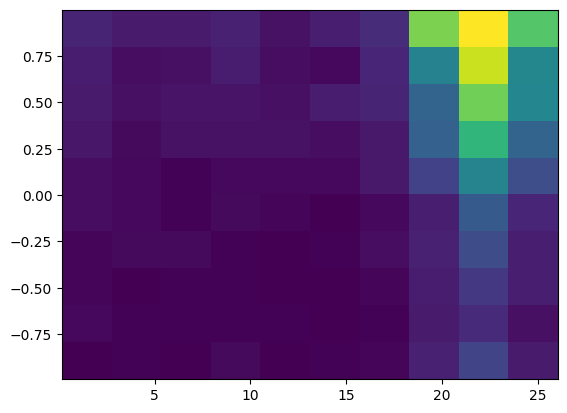

In [333]:
plt.pcolormesh(F3LILT_051225_gaze_distance_ratio_histogram['xedges'],F3LILT_051225_gaze_distance_ratio_histogram['yedges'],F3LILT_051225_gaze_distance_ratio_histogram['hist'].T)

In [342]:
sum(sum(F3LILT_051225_gaze_distance_ratio_histogram['hist'].T))

1862.0

In [334]:
F3LILT_051225_gaze_distance_port_ratio_histogram = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_port_ratio_histogram.npz")

In [366]:
def plot_clipped_histogram(npz_path, cmap='viridis', clip_percentile=95):
    data = np.load(npz_path)
    hist = data['hist']
    xedges = data['xedges']
    yedges = data['yedges']
    
    # Determine clipping threshold
    clip_value = np.percentile(hist, clip_percentile)
    
    plt.pcolormesh(xedges, yedges, np.clip(hist.T, 0, clip_value), 
                   cmap=cmap, shading='auto')
    plt.colorbar(label=f'Counts (clipped at {clip_percentile}%)')
    plt.xlabel('Distance from edge')
    plt.ylabel('Eye/Head rotation ratio')
    plt.title(f'Clipped (P{clip_percentile}) Gaze Distance-Ratio')
    plt.show()

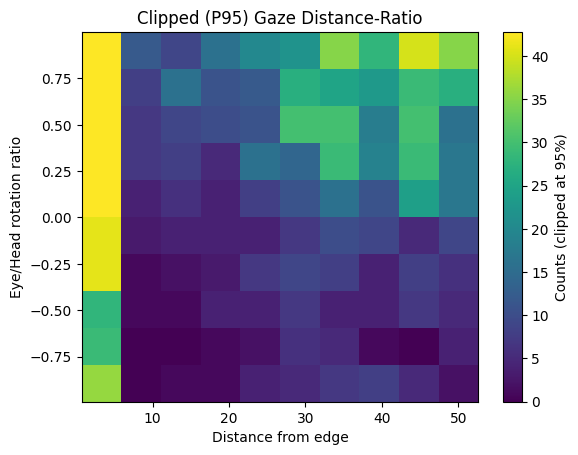

In [367]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_port_ratio_histogram.npz")

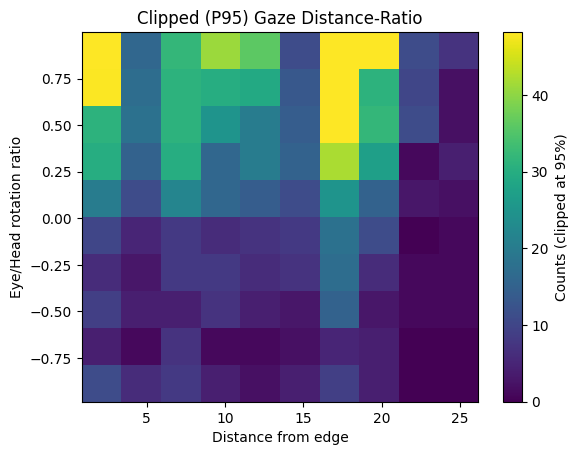

In [368]:
plot_clipped_histogram(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\F3LILT_051225_gaze_distance_ratio_histogram.npz", clip_percentile=95)

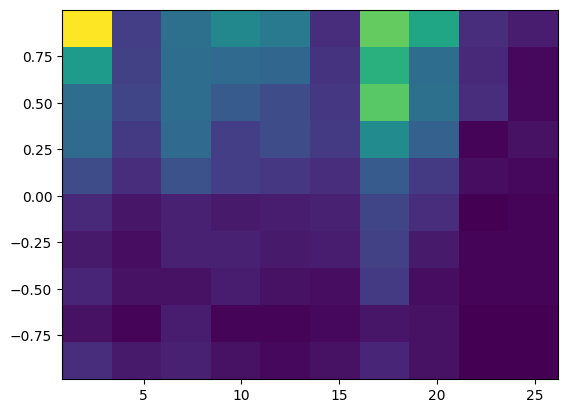

In [363]:
plt.pcolormesh(F3LILT_051225_gaze_distance_ratio_histogram['xedges'],F3LILT_051225_gaze_distance_ratio_histogram['yedges'],
               F3LILT_051225_gaze_distance_ratio_histogram['hist'].T/sum(sum(F3LILT_051225_gaze_distance_ratio_histogram['hist'].T)))

In [343]:
F3LILT_051225_gaze_distance_port_ratio_histogram['hist'].T/sum(sum(F3LILT_051225_gaze_distance_port_ratio_histogram['hist'].T))

array([[0.01784829, 0.        , 0.00049579, 0.00049579, 0.00198314,
        0.00247893, 0.0034705 , 0.00396629, 0.00247893, 0.00099157],
       [0.01437779, 0.        , 0.        , 0.00049579, 0.00099157,
        0.00297471, 0.00247893, 0.00049579, 0.        , 0.00198314],
       [0.013882  , 0.00049579, 0.00049579, 0.00198314, 0.00198314,
        0.0034705 , 0.00198314, 0.00198314, 0.0034705 , 0.00247893],
       [0.02032722, 0.00049579, 0.00099157, 0.00148736, 0.0034705 ,
        0.00446207, 0.00396629, 0.00198314, 0.00396629, 0.00297471],
       [0.02032722, 0.00148736, 0.00198314, 0.00198314, 0.00198314,
        0.0034705 , 0.00495786, 0.00446207, 0.00247893, 0.00446207],
       [0.03767972, 0.00198314, 0.00297471, 0.00198314, 0.00396629,
        0.00545364, 0.00793257, 0.00545364, 0.01189886, 0.00842836],
       [0.05999008, 0.0034705 , 0.00396629, 0.00247893, 0.00793257,
        0.006941  , 0.01437779, 0.00941993, 0.01437779, 0.00842836],
       [0.08081309, 0.0034705 , 0.0044620

ValueError: autodetected range of [nan, nan] is not finite

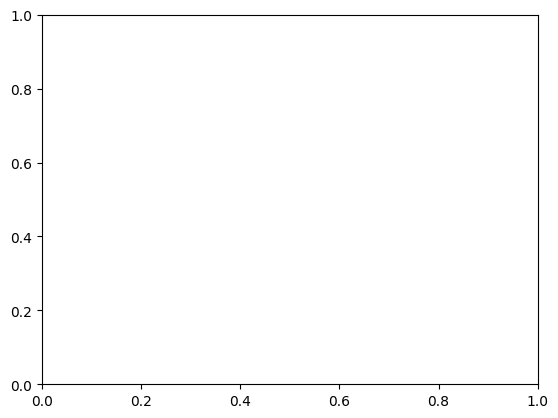

In [319]:
topT = flatten_list_of_arrays(F3LILT_051225_df['trial_timestamps'].to_list())-F3LILT_051225_imu['Openephys_time'][0]
dist = flatten_list_of_arrays(F3LILT_051225_df['head_cen_x_cm'].to_list())
#dist = dist[np.where(dist>0)[0]]

#opT = topT[np.where(dist>0)[0]]

event_indices_gazeL,frame_indices_gazeL=find_event_frames(topT,F3LILT_051225_imu['gazeL_event'])
event_indices_gazeR,frame_indices_gazeR=find_event_frames(topT,F3LILT_051225_imu['gazeR_event'])

gaze_inds_F3LILT_051225_imu_time_trial = np.hstack([event_indices_gazeL,event_indices_gazeR])
gaze_inds_trial = np.hstack([frame_indices_gazeL,frame_indices_gazeR])
gaze_inds = np.hstack([F3LILT_051225_imu['gazeL_idx'],F3LILT_051225_imu['gazeR_idx']])

ratio_during_task =compute_onset_ratios(F3LILT_051225_imu['dEye_dps'],F3LILT_051225_imu['dHead'],gaze_inds[gaze_inds_F3LILT_051225_imu_time_trial])

gazeR_ts_during_task = topT[frame_indices_gazeR]
gazeL_ts_during_task = topT[frame_indices_gazeL]


bad_indices = np.isnan(ratio_during_task)
good_indices = ~bad_indices


plt.hist2d(dist[gaze_inds_trial],ratio_during_task)
np.histogram2d(dist[gaze_inds_trial],ratio_during_task)

(array([[11.,  4.,  9.,  6., 10., 20., 30., 31., 48., 88.],
        [ 6.,  1.,  4.,  3.,  5., 11., 15., 18., 17., 16.],
        [ 8.,  7.,  4.,  8.,  8., 22., 30., 31., 31., 32.],
        [ 4.,  1.,  7.,  8.,  6., 16., 16., 25., 30., 41.],
        [ 2.,  1.,  4.,  6.,  7., 14., 20., 20., 29., 36.],
        [ 4.,  2.,  3.,  7.,  8., 11., 15., 14., 13., 11.],
        [ 9.,  5., 15., 17., 18., 25., 42., 65., 56., 67.],
        [ 4.,  4.,  3.,  6., 11., 15., 27., 32., 31., 52.],
        [ 0.,  0.,  1.,  1.,  0.,  3.,  1., 11., 10., 11.],
        [ 0.,  0.,  1.,  1.,  1.,  2.,  4.,  2.,  2.,  7.]]),
 array([ 0.83096577,  3.36564393,  5.90032209,  8.43500025, 10.96967841,
        13.50435657, 16.03903473, 18.57371289, 21.10839105, 23.64306921,
        26.17774738]),
 array([-0.98551277, -0.7869626 , -0.58841242, -0.38986224, -0.19131206,
         0.00723812,  0.20578829,  0.40433847,  0.60288865,  0.80143883,
         0.99998901]))

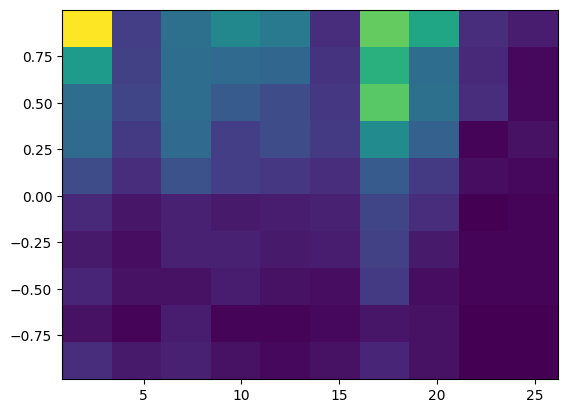

In [230]:
topT = flatten_list_of_arrays(df1['ts_trial_timestamps'].to_list())-imu['Openephys_time'][0]
dist = flatten_list_of_arrays(df1['ts_distance_from_edge'].to_list())
dist = dist[np.where(dist>0)[0]]

topT = topT[np.where(dist>0)[0]]

event_indices_gazeL,frame_indices_gazeL=find_event_frames(topT,imu['gazeL_event'])
event_indices_gazeR,frame_indices_gazeR=find_event_frames(topT,imu['gazeR_event'])

gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL,event_indices_gazeR])
gaze_inds_trial = np.hstack([frame_indices_gazeL,frame_indices_gazeR])
gaze_inds = np.hstack([imu['gazeL_idx'],imu['gazeR_idx']])

ratio_during_task =compute_onset_ratios(imu['dEye_dps'],imu['dHead'],gaze_inds[gaze_inds_imu_time_trial])

gazeR_during_task = imu['gazeR_event'][event_indices_gazeR]
gazeL_during_task = imu['gazeL_event'][event_indices_gazeL]

gazeR_ts_during_task = topT[frame_indices_gazeR]
gazeL_ts_during_task = topT[frame_indices_gazeL]


bad_indices = np.isnan(ratio_during_task)
good_indices = ~bad_indices


plt.hist2d(dist[gaze_inds_trial],ratio_during_task)
np.histogram2d(dist[gaze_inds_trial],ratio_during_task)

(array([1100., 1062.,  977., 1270.,  986., 1076., 1698., 1350.,  567.,
         343.]),
 array([ 0.09153421,  2.70015552,  5.30877684,  7.91739816, 10.52601947,
        13.13464079, 15.74326211, 18.35188343, 20.96050474, 23.56912606,
        26.17774738]),
 <BarContainer object of 10 artists>)

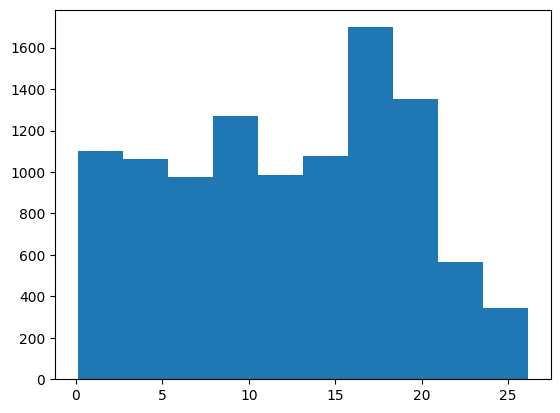

In [231]:
plt.hist(dist)

(array([[  3.,   0.,   2.,   7.,   5.,   6.,  13.,  12.,  11.,  16.],
        [  1.,   0.,   2.,   1.,   6.,   6.,   8.,   8.,  13.,   9.],
        [  1.,   0.,   2.,   2.,   1.,   3.,   7.,  10.,  16.,  12.],
        [  3.,   2.,   5.,   2.,   5.,   5.,   6.,  13.,  10.,  24.],
        [  0.,   3.,   4.,   5.,   6.,  10.,  17.,  15.,  14.,  20.],
        [  7.,   4.,   6.,  10.,   8.,  16.,  18.,  29.,  26.,  25.],
        [  8.,   3.,   4.,   7.,  10.,  15.,  29.,  28.,  28.,  36.],
        [  7.,   2.,   4.,   8.,   7.,  13.,  19.,  22.,  19.,  30.],
        [ 13.,  10.,  14.,  21.,  20.,  52.,  61.,  78.,  89., 112.],
        [ 26.,  25.,  20.,  25.,  27.,  49.,  88., 106., 138., 235.]]),
 array([ 0.68367573,  6.13537398, 11.58707223, 17.03877049, 22.49046874,
        27.942167  , 33.39386525, 38.8455635 , 44.29726176, 49.74896001,
        55.20065826]),
 array([-0.99378494, -0.79440754, -0.59503015, -0.39565276, -0.19627536,
         0.00310203,  0.20247943,  0.40185682,  0.601234

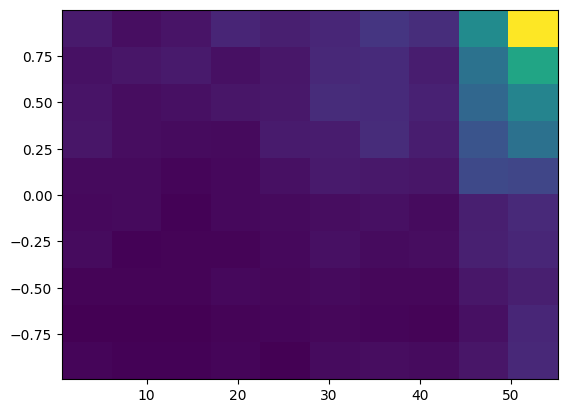

In [226]:
topT = flatten_list_of_arrays(df1['trial_timestamps'].to_list())-imu['Openephys_time'][0]
dist = flatten_list_of_arrays(df1['distance_from_target_port'].to_list())
dist = dist[np.where(dist>0)[0]]

topT = topT[np.where(dist>0)[0]]

event_indices_gazeL,frame_indices_gazeL=find_event_frames(topT,imu['gazeL_event'])
event_indices_gazeR,frame_indices_gazeR=find_event_frames(topT,imu['gazeR_event'])

gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL,event_indices_gazeR])
gaze_inds_trial = np.hstack([frame_indices_gazeL,frame_indices_gazeR])
gaze_inds = np.hstack([imu['gazeL_idx'],imu['gazeR_idx']])

ratio_during_task =compute_onset_ratios(imu['dEye_dps'],imu['dHead'],gaze_inds[gaze_inds_imu_time_trial])

gazeR_during_task = imu['gazeR_event'][event_indices_gazeR]
gazeL_during_task = imu['gazeL_event'][event_indices_gazeL]

gazeR_during_task = topT[frame_indices_gazeR]
gazeL_during_task = topT[frame_indices_gazeL]


bad_indices = np.isnan(ratio_during_task)
good_indices = ~bad_indices


plt.hist2d(dist[gaze_inds_trial],ratio_during_task)
np.histogram2d(dist[gaze_inds_trial],ratio_during_task)

(array([[ 36.,  29.,  28.,  41.,  41.,  76., 121., 163., 186., 303.],
        [  0.,   0.,   1.,   1.,   3.,   4.,   7.,   7.,   8.,  12.],
        [  1.,   0.,   1.,   2.,   4.,   6.,   8.,   9.,  16.,   9.],
        [  1.,   1.,   4.,   3.,   4.,   4.,   5.,  10.,  11.,  16.],
        [  4.,   2.,   4.,   7.,   4.,   8.,  16.,  11.,  12.,  20.],
        [  5.,   6.,   7.,   9.,   7.,  11.,  14.,  30.,  27.,  22.],
        [  7.,   5.,   4.,   8.,  10.,  16.,  29.,  30.,  25.,  35.],
        [  8.,   1.,   4.,   4.,   9.,  11.,  19.,  18.,  23.,  28.],
        [  5.,   0.,   7.,   8.,   5.,  24.,  29.,  30.,  29.,  40.],
        [  2.,   4.,   5.,   6.,   9.,  17.,  17.,  16.,  27.,  35.]]),
 array([ 0.69605928,  5.8879648 , 11.07987031, 16.27177582, 21.46368134,
        26.65558685, 31.84749236, 37.03939788, 42.23130339, 47.4232089 ,
        52.61511442]),
 array([-0.99378494, -0.79440754, -0.59503015, -0.39565276, -0.19627536,
         0.00310203,  0.20247943,  0.40185682,  0.601234

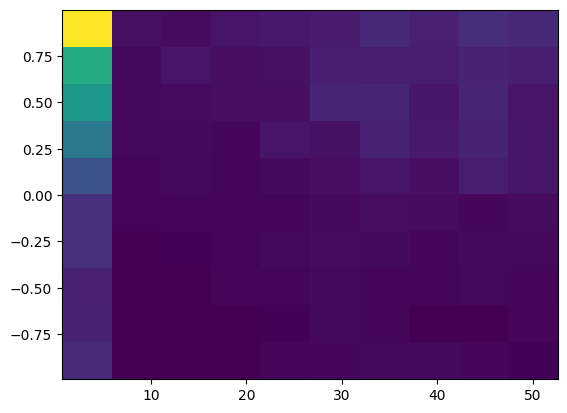

In [240]:
topT = flatten_list_of_arrays(df1['ts_trial_timestamps'].to_list())-imu['Openephys_time'][0]
dist = flatten_list_of_arrays(df1['ts_distance_from_target_port'].to_list())
dist = dist[np.where(dist>0)[0]]

topT = topT[np.where(dist>0)[0]]

event_indices_gazeL,frame_indices_gazeL=find_event_frames(topT,imu['gazeL_event'])
event_indices_gazeR,frame_indices_gazeR=find_event_frames(topT,imu['gazeR_event'])

gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL,event_indices_gazeR])
gaze_inds_trial = np.hstack([frame_indices_gazeL,frame_indices_gazeR])
gaze_inds = np.hstack([imu['gazeL_idx'],imu['gazeR_idx']])

ratio_during_task =compute_onset_ratios(imu['dEye_dps'],imu['dHead'],gaze_inds[gaze_inds_imu_time_trial])

gazeR_during_task = imu['gazeR_event'][event_indices_gazeR]
gazeL_during_task = imu['gazeL_event'][event_indices_gazeL]

gazeR_ts_during_task = topT[frame_indices_gazeR]
gazeL_ts_during_task = topT[frame_indices_gazeL]


bad_indices = np.isnan(ratio_during_task)
good_indices = ~bad_indices


plt.hist2d(dist[gaze_inds_trial],ratio_during_task)
np.histogram2d(dist[gaze_inds_trial],ratio_during_task)

(array([1430., 1048.,  908., 1022., 1144., 1571., 2411., 2450., 3365.,
        1652.]),
 array([ 0.69605928,  5.90379097, 11.11152265, 16.31925433, 21.52698601,
        26.7347177 , 31.94244938, 37.15018106, 42.35791275, 47.56564443,
        52.77337611]),
 <BarContainer object of 10 artists>)

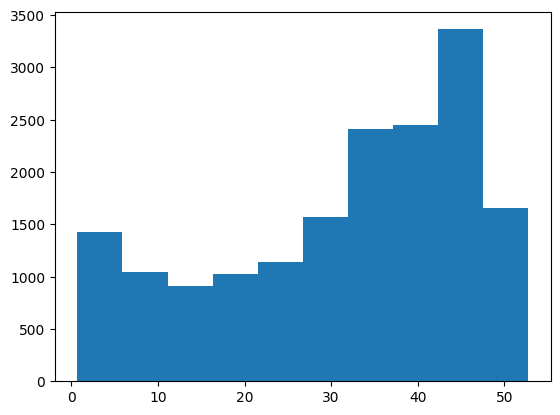

In [233]:
plt.hist(dist)

In [246]:
topT = flatten_list_of_arrays(df1['ts_trial_timestamps'].to_list())-imu['Openephys_time'][0]
dist = flatten_list_of_arrays(df1['ts_distance_from_edge'].to_list())
speed = flatten_list_of_arrays(df1['ts_speed'].to_list())

In [247]:
len(speed)

16929

In [248]:
len(dist)

17001

In [236]:
speed = flatten_list_of_arrays(df1['ts_speed'].to_list())

In [249]:
speed

array([10.90171566, 11.53497711, 12.6882236 , ...,  6.67675529,
        6.06147846,  5.72167793])

(array([2858., 1847., 1860., 1807., 2096., 2397., 1933., 1302.,  705.,
         124.]),
 array([ 0.08459909,  3.94227524,  7.79995139, 11.65762754, 15.51530369,
        19.37297984, 23.23065599, 27.08833214, 30.94600829, 34.80368444,
        38.66136059]),
 <BarContainer object of 10 artists>)

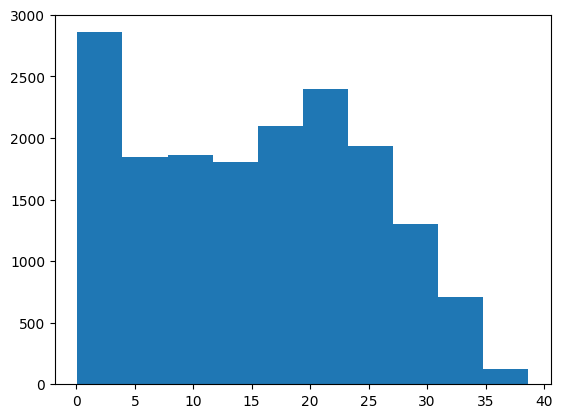

In [237]:
plt.hist(speed)

(array([[11.,  4.,  9.,  6., 10., 20., 30., 31., 48., 88.],
        [ 6.,  1.,  4.,  3.,  5., 11., 15., 18., 17., 16.],
        [ 8.,  7.,  4.,  8.,  8., 22., 30., 31., 31., 32.],
        [ 4.,  1.,  7.,  8.,  6., 16., 16., 25., 30., 41.],
        [ 2.,  1.,  4.,  6.,  7., 14., 20., 20., 29., 36.],
        [ 4.,  2.,  3.,  7.,  8., 11., 15., 14., 13., 11.],
        [ 9.,  5., 15., 17., 18., 25., 42., 65., 56., 67.],
        [ 4.,  4.,  3.,  6., 11., 15., 27., 32., 31., 52.],
        [ 0.,  0.,  1.,  1.,  0.,  3.,  1., 11., 10., 11.],
        [ 0.,  0.,  1.,  1.,  1.,  2.,  4.,  2.,  2.,  7.]]),
 array([ 0.83096577,  3.36564393,  5.90032209,  8.43500025, 10.96967841,
        13.50435657, 16.03903473, 18.57371289, 21.10839105, 23.64306921,
        26.17774738]),
 array([-0.98551277, -0.7869626 , -0.58841242, -0.38986224, -0.19131206,
         0.00723812,  0.20578829,  0.40433847,  0.60288865,  0.80143883,
         0.99998901]))

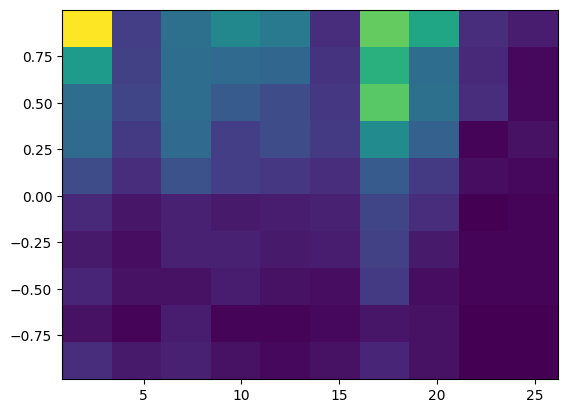

In [243]:
topT = flatten_list_of_arrays(df1['ts_trial_timestamps'].to_list())-imu['Openephys_time'][0]
dist = flatten_list_of_arrays(df1['ts_distance_from_edge'].to_list())
speed = flatten_list_of_arrays(df1['ts_speed'].to_list())
dist = dist[np.where(dist>0)[0]]
topT = topT[np.where(dist>0)[0]]
speed = speed[np.where(dist>0)[0]]

event_indices_gazeL,frame_indices_gazeL=find_event_frames(topT,imu['gazeL_event'])
event_indices_gazeR,frame_indices_gazeR=find_event_frames(topT,imu['gazeR_event'])

gaze_inds_imu_time_trial = np.hstack([event_indices_gazeL,event_indices_gazeR])
gaze_inds_trial = np.hstack([frame_indices_gazeL,frame_indices_gazeR])
gaze_inds = np.hstack([imu['gazeL_idx'],imu['gazeR_idx']])

ratio_during_task =compute_onset_ratios(imu['dEye_dps'],imu['dHead'],gaze_inds[gaze_inds_imu_time_trial])

gazeR_during_task = imu['gazeR_event'][event_indices_gazeR]
gazeL_during_task = imu['gazeL_event'][event_indices_gazeL]

gazeR_ts_during_task = topT[frame_indices_gazeR]
gazeL_ts_during_task = topT[frame_indices_gazeL]


bad_indices = np.isnan(ratio_during_task)
good_indices = ~bad_indices


plt.hist2d(dist[gaze_inds_trial],ratio_during_task)
np.histogram2d(dist[gaze_inds_trial],ratio_during_task)

In [559]:
import numpy as np

def filter_values_within_range(main_array, range_array):
    """
    Filters values from main_array that fall within the first and last elements of range_array,
    returns the filtered values, their indices in main_array, and the closest match indices in range_array.
    
    Parameters:
    - main_array: numpy.ndarray
        The array of floats to filter.
    - range_array: numpy.ndarray
        The array whose first and last elements define the range.
        
    Returns:
    - tuple: (filtered_values, indices_in_main_array, indices_in_range_array)
        - filtered_values: numpy.ndarray
            The filtered array containing values within the specified range.
        - indices_in_main_array: numpy.ndarray
            The indices of the filtered values in main_array.
        - indices_in_range_array: numpy.ndarray
            The indices of the closest matches in range_array for each filtered value.
    """
    if len(range_array) == 0:
        raise ValueError("range_array must not be empty")
    
    lower_bound = min(range_array[0], range_array[-1])
    upper_bound = max(range_array[0], range_array[-1])
    
    # Mask for values in main_array within bounds
    mask_main = (main_array >= lower_bound) & (main_array <= upper_bound)
    filtered_values = main_array[mask_main]
    indices_in_main_array = np.where(mask_main)[0]  # Indices of filtered values in main_array
    
    # For each filtered value, find the index of the closest value in range_array
    indices_in_range_array = np.array([
        np.argmin(np.abs(range_array - val)) for val in filtered_values
    ])
    
    return filtered_values, indices_in_main_array, indices_in_range_array



In [250]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable

def create_speed_colormap():
    # Define bin boundaries for speed (0-50)
    speed_bounds = [0, 12.5, 25, 37.5, 50]  # 4 equal bins
    
    # Green to purple color scheme (no blue/red)
    speed_colors = [
        [0.8, 0.9, 0.7, 1],    # Light green (slowest)
        [0.5, 0.8, 0.3, 1],     # Medium green
        [0.7, 0.4, 0.8, 1],     # Lavender
        [0.5, 0.1, 0.5, 1]      # Dark purple (fastest)
    ]
    
    # Create colormap and normalization
    speed_cmap = ListedColormap(speed_colors)
    speed_norm = BoundaryNorm(speed_bounds, speed_cmap.N)
    
    return speed_cmap, speed_norm, speed_bounds


In [252]:
speed_cmap, speed_norm, speed_bounds = create_speed_colormap()

In [267]:
speed_colors

array([[0.8, 0.9, 0.7, 1. ],
       [0.8, 0.9, 0.7, 1. ],
       [0.8, 0.9, 0.7, 1. ],
       [0.8, 0.9, 0.7, 1. ],
       [0.8, 0.9, 0.7, 1. ],
       [0.8, 0.9, 0.7, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0.8, 0.3, 1. ],
       [0.5, 0

In [269]:
speed_colors.shape

(159, 4)

In [258]:
len(ts_trial_vidframes)

159

In [ ]:
speed_colors

(4,)

(0.0, 61.0, 51.0, 0.0)

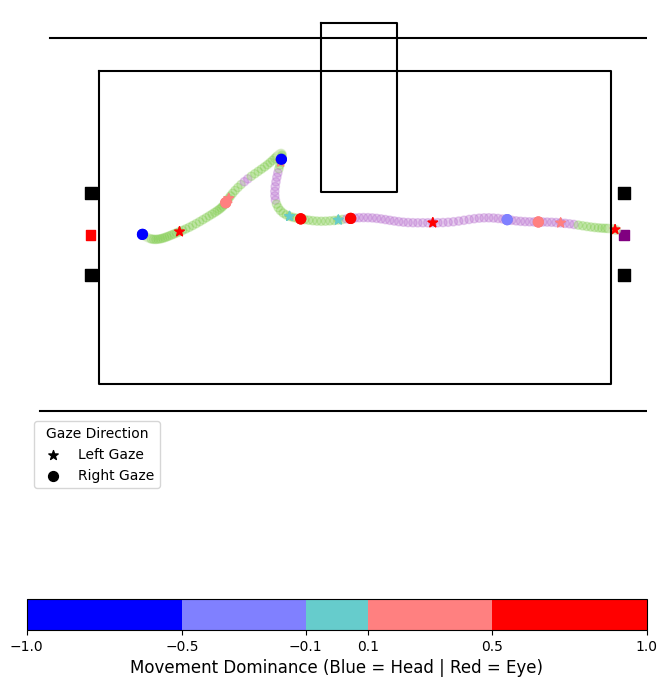

In [280]:



# Define your bin boundaries
bounds = [-1, -0.5, -0.1, 0.1, 0.5, 1]

# Define colors for each bin (R,G,B,A)
colors = [
    (0, 0, 1, 1),        # Dark blue for values < -0.5
    (0.5, 0.5, 1, 1),    # Lighter blue (-0.5 to -0.1)
    (0.4, 0.8, 0.8, 1),   # Light grey
    (1, 0.5, 0.5, 1),    # Light red (0.1 to 0.5)
    (1, 0, 0, 1)         # Dark red (> 0.5)
]

# Create the colormap and normalization
cmap = ListedColormap(colors)
norm = BoundaryNorm(bounds, cmap.N)

speed_cmap, speed_norm, speed_bounds = create_speed_colormap()





test_df = df1.iloc[[13]]
dEye_dps =imu['dEye_dps']
dHead =imu['dHead']
dGaze =imu['dGaze']
eyeT =imu['eyeT']
speed_colors = speed_cmap(speed_norm(test_df.ts_speed.to_numpy()[0]))
speed_colors = np.concatenate((speed_colors,speed_colors[0].reshape(1, -1)), axis=0)

trial_imu_corected = test_df.ts_trial_timestamps.to_numpy()[0]-imu['Openephys_time'][0]
ts_trial_vidframes = test_df.ts_trial_vidframes.to_numpy()[0]

start_timestamp, start_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[0]))
end_timestamp, end_index = find_closest(eyeT.flatten()[:-1], np.array(trial_imu_corected[-1]))
dEye_dps_trial = dEye_dps[start_index:end_index]
dHead_trial = dHead[start_index:end_index]
dGaze_trial = dGaze[start_index:end_index]
eyeT_trial = eyeT.flatten()[:-1][start_index:end_index]\

gazeL_trial_event, gazeR_trial_event, compL_trial_event, compR_trial_event, \
    gazeL_trial_idx, gazeR_trial_idx, compL_trial_idx, compR_trial_idx = classify_gaze_movements(
        dHead_trial, dGaze_trial, eyeT_trial)

compute_onset_ratios(dEye_dps_trial,dHead_trial,gazeL_trial_idx)

fig,ax = plt.subplots(figsize = (8,9))

plot_arena(test_df,ax)
plot_orginal_obstacle(test_df,ax,4)

l_gaze_ratio = compute_onset_ratios(dEye_dps_trial,dHead_trial,gazeL_trial_idx)
l_gaze_c = cmap(norm(l_gaze_ratio))

r_gaze_ratio = compute_onset_ratios(dEye_dps_trial,dHead_trial,gazeR_trial_idx)
r_gaze_c = cmap(norm(r_gaze_ratio))




ax.scatter(test_df.ts_head_cen_x_cm.to_numpy()[0][gazeL_trial_idx],test_df.ts_head_cen_y_cm.to_numpy()[0][gazeL_trial_idx]
           , c = l_gaze_c,s = 50,marker ='*')

ax.scatter(test_df.ts_head_cen_x_cm.to_numpy()[0][gazeR_trial_idx],test_df.ts_head_cen_y_cm.to_numpy()[0][gazeR_trial_idx]
          , c = r_gaze_c,s = 50)

# Create a ScalarMappable for the colorbar
sm = ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar


ax.scatter(test_df.ts_head_cen_x_cm.to_numpy()[0],test_df.ts_head_cen_y_cm.to_numpy()[0],c =speed_colors ,alpha=.3)


cbar = plt.colorbar(sm, ax=ax, boundaries=bounds, ticks=bounds,
                   spacing='proportional', orientation='horizontal')
cbar.set_label('Movement Dominance (Blue = Head | Red = Eye)', fontsize=12)
#cbar.ax.set_xticklabels(['-1.0\n(Head)', '-0.5', 'Neutral', '0.5', '1.0\n(Eye)'], fontsize=9)

# Create scatter plots and store their handles
left_gaze = ax.scatter([], [], c='black', s=50, marker='*', label='Left Gaze')  # Empty scatter for legend
right_gaze = ax.scatter([], [], c='black', s=50, marker='o', label='Right Gaze')  # Empty scatter for legend

# Plot your actual data (keep your existing scatter plots)
ax.scatter(test_df.ts_head_cen_x_cm.to_numpy()[0][gazeL_trial_idx],
           test_df.ts_head_cen_y_cm.to_numpy()[0][gazeL_trial_idx],
           c=l_gaze_c, s=50, marker='*')

ax.scatter(test_df.ts_head_cen_x_cm.to_numpy()[0][gazeR_trial_idx],
           test_df.ts_head_cen_y_cm.to_numpy()[0][gazeR_trial_idx],
           c=r_gaze_c, s=50, marker='o')

# Add the legend
legend = ax.legend(handles=[left_gaze, right_gaze], 
                   loc='lower left', 
                   title="Gaze Direction",
                   frameon=True,
                   framealpha=0.8)
ax.axis('off')




In [295]:
import os
import matplotlib.pyplot as plt
from matplotlib.backends.backend_pdf import PdfPages
import numpy as np
from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.cm import ScalarMappable
from matplotlib.lines import Line2D

def create_gaze_pdf_report(df, imu_data, output_filename='gaze_report.pdf', output_dir='.'):
    """
    Create a PDF report with gaze analysis plots.
    
    Parameters:
    -----------
    df : DataFrame
        Input data containing trial information
    imu_data : dict
        IMU data dictionary with keys: ['dEye_dps', 'dHead', 'dGaze', 'eyeT', 'Openephys_time']
    output_filename : str, optional
        Name of the output PDF file (default: 'gaze_report.pdf')
    output_dir : str, optional
        Directory where the PDF will be saved (default: current directory)
    """
    # Create output directory if it doesn't exist
    os.makedirs(output_dir, exist_ok=True)
    output_path = os.path.join(output_dir, output_filename)
    
    # Define gaze colormap (head-eye dominance)
    bounds = [-1, -0.5, -0.1, 0.1, 0.5, 1]
    colors = [
        (0, 0, 1, 1),        # Dark blue
        (0.5, 0.5, 1, 1),    # Lighter blue
        (0.4, 0.8, 0.8, 1),   # Light grey
        (1, 0.5, 0.5, 1),    # Light red
        (1, 0, 0, 1)         # Dark red
    ]
    cmap = ListedColormap(colors)
    norm = BoundaryNorm(bounds, cmap.N)


    # Define speed colormap (0-50)
    speed_bounds = [0, 12.5, 25, 37.5, 50]
    speed_colors = [
        [0.8, 0.9, 0.7, 1],    # Light green
        [0.5, 0.8, 0.3, 1],     # Medium green
        [0.7, 0.4, 0.8, 1],     # Lavender
        [0.5, 0.1, 0.5, 1]      # Dark purple
    ]
    speed_cmap = ListedColormap(speed_colors)
    speed_norm = BoundaryNorm(speed_bounds, speed_cmap.N)

    
    with PdfPages(output_path) as pdf:
        rows_per_page = 9
        total_pages = int(np.ceil(len(df) / rows_per_page))
        
        for page_num in range(total_pages):
            fig, axes = plt.subplots(3, 3, figsize=(15, 15))
            axes = axes.flatten()
            
            start_idx = page_num * rows_per_page
            end_idx = min((page_num + 1) * rows_per_page, len(df))
            page_rows = df.iloc[start_idx:end_idx]
            
            for i, (ax, (_, row)) in enumerate(zip(axes, page_rows.iterrows())):
                try:
                    # Process IMU data for this trial
                    trial_imu_corrected = row.ts_trial_timestamps - imu_data['Openephys_time'][0]
                    
                    # Find closest timestamps
                    start_timestamp, start_index = find_closest(imu_data['eyeT'].flatten()[:-1], trial_imu_corrected[0])
                    end_timestamp, end_index = find_closest(imu_data['eyeT'].flatten()[:-1], trial_imu_corrected[-1])
                    
                    # Extract trial data
                    dEye_dps_trial = imu_data['dEye_dps'][start_index:end_index]
                    dHead_trial = imu_data['dHead'][start_index:end_index]
                    dGaze_trial = imu_data['dGaze'][start_index:end_index]
                    eyeT_trial = imu_data['eyeT'].flatten()[:-1][start_index:end_index]
                    
                    # Classify gaze movements
                    gaze_results = classify_gaze_movements(dHead_trial, dGaze_trial, eyeT_trial)
                    gazeL_trial_idx = gaze_results[4]
                    gazeR_trial_idx = gaze_results[5]
                    
                    # Compute onset ratios and colors
                    l_gaze_ratio = compute_onset_ratios(dEye_dps_trial, dHead_trial, gazeL_trial_idx)
                    r_gaze_ratio = compute_onset_ratios(dEye_dps_trial, dHead_trial, gazeR_trial_idx)
                    l_gaze_c = cmap(norm(l_gaze_ratio))
                    r_gaze_c = cmap(norm(r_gaze_ratio))


                    speed_colors = speed_cmap(speed_norm(row.ts_speed))
                    speed_colors = np.concatenate((speed_colors,speed_colors[0].reshape(1, -1)), axis=0)
                    
                    # Plot arena and obstacle
                    plot_arena(row.to_frame().T, ax)
                    plot_orginal_obstacle(row.to_frame().T, ax, row.obstacle_cluster)

                    # Plot head trajectory
                    ax.scatter(row.ts_head_cen_x_cm, row.ts_head_cen_y_cm,c =speed_colors ,alpha=.3)
                    
                    # Plot gaze points
                    ax.scatter(row.ts_head_cen_x_cm[gazeL_trial_idx],
                              row.ts_head_cen_y_cm[gazeL_trial_idx],
                              c=l_gaze_c, s=50, marker='*')
                    ax.scatter(row.ts_head_cen_x_cm[gazeR_trial_idx],
                              row.ts_head_cen_y_cm[gazeR_trial_idx],
                              c=r_gaze_c, s=50, marker='o')
                    
                    
                    
                    # Add trial title
                    trial_id = getattr(row, 'trial_id', f'Trial {start_idx + i + 1}')
                    ax.set_title(trial_id, fontsize=10)
                    ax.axis('off')
                    
                except Exception as e:
                    print(f"Error processing row {start_idx + i}: {str(e)}")
                    ax.axis('off')
                    ax.text(0.5, 0.5, f"Error\n{str(e)}", ha='center', va='center', color='red')
            
            # Add colorbar to the figure
            cbar_ax = fig.add_axes([0.25, 1, 0.5, 0.02])
            sm = ScalarMappable(cmap=cmap, norm=norm)
            sm.set_array([])
            cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal')
            cbar.set_ticks(bounds)
            cbar.set_label('Movement Dominance\n(Blue = Head | Red = Eye)', fontsize=10)
            
            # Add speed colorbar (bottom) if speed data provided
            speed_cax = fig.add_axes([0.25, 0, 0.5, 0.02])
            speed_sm = ScalarMappable(cmap=speed_cmap, norm=speed_norm)
            speed_sm.set_array([])
            speed_cbar = fig.colorbar(speed_sm, cax=speed_cax, orientation='horizontal')
            speed_cbar.set_label('Speed (0-50)', fontsize=10)
            speed_cbar.set_ticks(speed_bounds)
            #speed_cbar.set_ticklabels(['0-12.5', '12.5-25', '25-37.5', '37.5-50'])
            
            # Add legend
            legend_elements = [
                Line2D([0], [0], marker='*', color='w', label='Left Gaze',
                      markerfacecolor='black', markersize=10),
                Line2D([0], [0], marker='o', color='w', label='Right Gaze',
                      markerfacecolor='black', markersize=10)
            ]
            fig.legend(handles=legend_elements, loc='lower right', 
                      bbox_to_anchor=(0.9, 0.05), frameon=True)
            
            # Adjust layout and save page
            fig.tight_layout(rect=[0, 0, 0.9, 1])
            pdf.savefig(fig, bbox_inches='tight')
            plt.close(fig)
    
    print(f"PDF report successfully saved to: {output_path}")

In [289]:
df1.animal

0     F3LILT
1     F3LILT
2     F3LILT
3     F3LILT
4     F3LILT
       ...  
67    F3LILT
68    F3LILT
69    F3LILT
70    F3LILT
71    F3LILT
Name: animal, Length: 72, dtype: object

In [287]:
create_gaze_pdf_report(df=df1, imu_data=imu, output_filename='gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\gaze_report.pdf


In [ ]:
F3LILT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\cluster_F3LILT_051225_oa.h5")
F3LILT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam\051225_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_051225_df)
calculate_speed(F3LILT_051225_df)
create_gaze_pdf_report(df=F3LILT_051225_df, imu_data=F3LILT_051225_imu, output_filename='F3LILT_051225_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LILT\oa_cam")

In [297]:
F3LILT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\cluster_F3LILT_051325_oa.h5")
F3LILT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\051325_F3LILT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LILT_051325_df)
calculate_speed(F3LILT_051325_df)
create_gaze_pdf_report(df=F3LILT_051325_df, imu_data=F3LILT_051325_imu, output_filename='F3LILT_051325_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051325\F3LILT\oa_cam\F3LILT_051325_df_new_gaze_report.pdf


In [298]:
F3LITT_051225_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\cluster_F3LITT_051225_oa.h5")
F3LITT_051225_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\051225_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_051225_df)
calculate_speed(F3LITT_051225_df)
create_gaze_pdf_report(df=F3LITT_051225_df, imu_data=F3LITT_051225_imu, output_filename='F3LITT_051225_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051225\F3LITT\oa_cam\F3LITT_051225_df_new_gaze_report.pdf


In [299]:
F3LITT_051325_df = pd.read_hdf(
    r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\cluster_F3LITT_051325_oa.h5")
F3LITT_051325_imu = np.load(r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\051325_F3LITT_imu_eyecam_dict.npz")
calculate_relative_distance(F3LITT_051325_df)
calculate_speed(F3LITT_051325_df)
create_gaze_pdf_report(df=F3LITT_051325_df, imu_data=F3LITT_051325_imu, output_filename='F3LITT_051325_df_new_gaze_report.pdf'
                       , output_dir=r"\\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam")

PDF report successfully saved to: \\goeppert\Vol2\mike\recordings\051325\F3LITT\oa_cam\F3LITT_051325_df_new_gaze_report.pdf


(array([ 85.,  70.,  73.,  91., 121., 172., 287., 307., 348., 523.]),
 array([-0.9998438 , -0.79986052, -0.59987724, -0.39989396, -0.19991068,
         0.0000726 ,  0.20005588,  0.40003916,  0.60002244,  0.80000572,
         0.99998901]),
 <BarContainer object of 10 artists>)

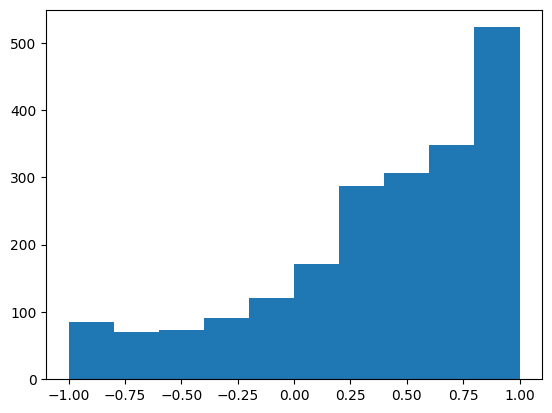

In [104]:
ratio_F3LILT_051225 = compute_onset_ratios(F3LILT_051225_imu['dEye_dps'],F3LILT_051225_imu['dHead'],
                                           np.hstack((F3LILT_051225_imu['gazeL_idx'],F3LILT_051225_imu['gazeR_idx'])))
plt.hist(ratio_F3LILT_051225)